<a href="https://colab.research.google.com/github/sevshz/legal-123-data/blob/main/Legal_123_Data_Investigative_Project_Group_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Legal Studies 123 Data Investigative Project Exploratory Data Analysis: Examining the Relationship Between Gun Law Severity and Mass Shootings in the United States (2015-2025)

**Group 1 - Ayushi Mody, Arly Siu, Arianna Villarreal, Sevana Zadoian**

# Section I. Preliminaries


In [78]:
# dependencies
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
!pip install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import sklearn.metrics as metrics

import seaborn as sns
!pip install plotly
import plotly.offline as py
py.init_notebook_mode(connected=True)
from IPython.display import display, HTML # makes the output in Jupyter notebook pretty
import plotly.express as px
import plotly.io as pio
import folium
from folium.plugins import TimestampedGeoJson
import json
import copy
import requests

import random
random.seed(42)

# Our Question: Can Number of Mass Shootings or Party Composition Predict the Severity of Gun Laws in a State?

# Section II. Data Collection and Structuring

## a. Encoding *Giffords Annual Gun Law Scorecard*

**The following two cells are how we encoded the Giffords Annual Gun Law Scorecard. The raw historical data for scoring was not publicly available, so we hard coded the A-F scale rankings on our previously decided integer scale (1-5). Plus/minus distinctions were normalized to just their letter grades.**

In [79]:
giffords_2015 = {
    'Year': [2015]*50,

    'State': [
        'California','Connecticut','New Jersey','Maryland','Massachusetts',
        'New York','Hawaii','Illinois','Rhode Island','Delaware',
        'Washington','Minnesota','Pennsylvania','Oregon','Michigan',
        'Colorado','Iowa','Wisconsin','Ohio','Virginia',
        'Nebraska','New Hampshire','Indiana','West Virginia','Oklahoma',
        'North Carolina','Nevada','South Carolina','Georgia','Florida',
        'North Dakota','Tennessee','New Mexico','Texas','Maine',
        'Alabama','Montana','Arkansas','Utah','South Dakota',
        'Missouri','Vermont','Kentucky','Louisiana','Idaho',
        'Alaska','Arizona','Wyoming','Mississippi','Kansas'
    ],

    'Giffords_Rank': [5, 5, 5, 5, 5, 5, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2,
             1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],

    'Gun Death Rate Rank': [
        42,47,45,36,49,
        48,50,40,46,32,
        39,43,27,28,22,
        25,41,35,29,33,
        38,44,18,13,8,
        21,16,11,20,23,
        24,10,9,31,30,
        4,5,6,19,34,
        12,37,17,2,14,
        1,15,7,3,26
    ]
}

giffords_2016 = {
    'Year': [2016]*50,

    'State': [
        'California','Connecticut','New Jersey','Massachusetts','Maryland',
        'New York','Hawaii','Illinois','Rhode Island','Washington',
        'Delaware','Minnesota','Pennsylvania','Colorado','Oregon',
        'Iowa','Michigan','Nevada','Wisconsin','Nebraska',
        'Ohio','Virginia','New Hampshire','Indiana','North Carolina',
        'Florida','Oklahoma','Tennessee','Georgia','New Mexico',
        'North Dakota','South Carolina','Utah','Texas','West Virginia',
        'Maine','Alabama','Arkansas','Montana','South Dakota',
        'Vermont','Kentucky','Louisiana','Alaska','Wyoming',
        'Idaho','Arizona','Kansas','Missouri','Mississippi'
    ],

    'Giffords_Rank': [
        5,5,5,5,5,5,5,   # A range
        4,4,4,           # B range
        3,3,3,3,3,3,3,   # C range
        2,2,2,2,2,2,2,   # D range
        *([1]*26)        # F range
    ],

    'Gun Death Rate Rank': [
        43,46,45,50,27,
        48,49,39,47,37,
        24,44,32,22,30,
        42,29,14,35,41,
        26,34,40,21,23,
        25,8,12,16,7,
        20,10,19,28,17,
        36,3,11,6,33,
        38,13,2,1,4,
        15,18,31,9,5
    ]
}

giffords_2017 = {
    'Year': [2017]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Giffords_Rank': [
        1,1,1,1,5,
        3,5,4,1,1,
        5,1,4,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,2,2,1,5,
        1,5,2,1,2,
        1,3,3,4,1,
        1,2,1,1,1,
        2,4,2,3,1
    ],

    'Gun Death Rate Rank': [
        2,1,16,9,43,
        20,46,37,28,17,
        47,19,34,18,39,
        23,13,3,42,32,
        50,27,44,4,7,
        6,40,15,38,45,
        8,48,21,30,25,
        5,33,31,49,10,
        22,14,28,24,36,
        29,41,12,35,11
    ]
}
giffords_2018 = {
    'Year': [2018]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Giffords_Rank': [
        1,1,1,1,5,
        3,5,4,3,1,
        5,1,4,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,3,2,1,5,
        1,5,2,2,2,
        1,3,4,4,1,
        1,2,1,2,2,
        2,4,1,3,1
    ],

    'Gun Death Rate Rank': [
        2,1,18,7,44,
        24,46,36,28,19,
        50,15,31,20,41,
        17,16,4,35,29,
        49,37,43,5,6,
        3,42,14,40,45,
        10,48,23,25,22,
        13,47,26,47,12,
        33,11,27,21,34,
        32,38,9,39,8
    ]
}
giffords_2019 = {
    'Year': [2019]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Giffords_Rank': [
        1,1,1,1,5,
        3,5,4,3,1,
        5,1,5,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,3,4,1,5,
        3,5,2,1,2,
        1,3,4,4,1,
        1,2,1,2,2,
        2,4,1,3,1
    ],

    'Gun Death Rate Rank': [
        2,7,18,8,44,
        19,45,34,27,17,
        48,16,36,20,42,
        21,14,4,39,33,
        49,26,43,1,3,
        13,41,10,37,46,
        6,47,23,35,25,
        15,32,29,50,12,
        22,11,30,24,28,
        31,38,9,40,5
    ]
}
giffords_2020 = {
    'Year': [2020]*50,

    'State': [
        'Alabama','Alaska','Arizona','Arkansas','California',
        'Colorado','Connecticut','Delaware','Florida','Georgia',
        'Hawaii','Idaho','Illinois','Indiana','Iowa',
        'Kansas','Kentucky','Louisiana','Maine','Maryland',
        'Massachusetts','Michigan','Minnesota','Mississippi','Missouri',
        'Montana','Nebraska','Nevada','New Hampshire','New Jersey',
        'New Mexico','New York','North Carolina','North Dakota','Ohio',
        'Oklahoma','Oregon','Pennsylvania','Rhode Island','South Carolina',
        'South Dakota','Tennessee','Texas','Utah','Vermont',
        'Virginia','Washington','West Virginia','Wisconsin','Wyoming'
    ],

    'Giffords_Rank': [
        1,1,1,1,5,
        3,5,4,3,1,
        5,1,5,2,3,
        1,1,1,1,5,
        5,3,3,1,1,
        1,3,4,1,5,
        3,5,2,1,2,
        1,3,4,4,1,
        1,2,1,2,2,
        2,4,1,3,1
    ],

    'Gun Death Rate Rank': [
        5,1,16,9,44,
        18,45,40,26,14,
        47,19,35,20,42,
        21,17,6,34,28,
        50,31,43,2,7,
        10,38,15,37,48,
        4,49,23,29,22,
        11,30,32,46,8,
        24,12,27,25,41,
        33,36,13,39,3
    ]
}

In [80]:
giffords_2021 = {
    'Year': [2021]*50,

    'State': [
        'California', 'New Jersey', 'Connecticut', 'Hawaii', 'Illinois',
        'Maryland', 'Massachusetts', 'New York', 'Colorado', 'Delaware',
        'Rhode Island', 'Virginia', 'Washington', 'Oregon', 'Pennsylvania',
        'Michigan', 'Minnesota', 'Nevada', 'New Mexico', 'Florida',
        'Nebraska', 'North Carolina', 'Vermont', 'Wisconsin', 'Ohio',
        'Indiana', 'Alabama', 'Alaska', 'Arizona', 'Arkansas',
        'Georgia', 'Idaho', 'Iowa', 'Kansas', 'Kentucky',
        'Louisiana', 'Maine', 'Mississippi', 'Missouri', 'Montana',
        'New Hampshire', 'North Dakota', 'Oklahoma', 'South Carolina', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Giffords_Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        3, 3, 3, 3, 2,
        2, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 48, 45, 50, 27,
        33, 49, 46, 22, 25,
        47, 34, 39, 35, 31,
        24, 43, 18, 7, 29,
        41, 21, 37, 36, 23,
        17, 5, 6, 20, 8,
        15, 16, 38, 19, 13,
        22, 40, 1, 4, 11,
        42, 28, 12, 9, 32,
        10, 26, 30, 14, 3
    ]
}

giffords_2022 = {
    'Year': [2022]*50,

    'State': [
        'California', 'New Jersey', 'Connecticut', 'Hawaii', 'Illinois',
        'Maryland', 'Massachusetts', 'New York', 'Oregon', 'Rhode Island',
        'Washington', 'Colorado', 'Delaware', 'Virginia', 'Pennsylvania',
        'Michigan', 'Minnesota', 'Nevada', 'New Mexico', 'Nebraska',
        'North Carolina', 'Florida', 'Vermont', 'Wisconsin', 'Alabama',
        'Alaska', 'Arizona', 'Arkansas', 'Georgia', 'Idaho',
        'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Mississippi', 'Missouri', 'Montana', 'New Hampshire',
        'North Dakota', 'Ohio', 'Oklahoma', 'South Carolina', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Giffords_Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        3, 3, 3, 2, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        43, 48, 45, 49, 26,
        29, 50, 47, 30, 46,
        39, 18, 23, 32, 31,
        28, 42, 15, 3, 41,
        21, 34, 38, 36, 4,
        6, 17, 8, 14, 25,
        16, 40, 20, 13, 22,
        37, 1, 9, 7, 44,
        22, 24, 12, 11, 33,
        10, 27, 35, 19, 5
    ]
}

giffords_2023 = {
    'Year': [2023]*50,

    'State': [
        'California', 'Connecticut', 'New Jersey', 'Colorado', 'Hawaii',
        'Illinois', 'Maryland', 'Massachusetts', 'New York', 'Oregon',
        'Washington', 'Delaware', 'Rhode Island', 'Virginia', 'Minnesota',
        'Pennsylvania', 'Michigan', 'Nevada', 'Vermont', 'New Mexico',
        'Wisconsin', 'Nebraska', 'North Carolina', 'Florida', 'Indiana',
        'Maine', 'New Hampshire', 'Ohio', 'South Carolina', 'Alabama',
        'Alaska', 'Arizona', 'Arkansas', 'Georgia', 'Idaho',
        'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Mississippi',
        'Missouri', 'Montana', 'North Dakota', 'Oklahoma', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Giffords_Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 5, 5,
        5, 4, 4, 4, 4,
        4, 4, 4, 4, 3,
        3, 3, 3, 2, 2,
        2, 2, 2, 2, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 45, 47, 19, 48,
        32, 35, 49, 46, 30,
        36, 39, 50, 28, 43,
        29, 27, 15, 38, 3,
        33, 37, 20, 31, 17,
        40, 42, 26, 9, 4,
        7, 12, 8, 14, 18,
        41, 21, 16, 22, 1,
        6, 5, 22, 13, 24,
        10, 25, 34, 23, 11
    ]
}

giffords_2024 = {
    'Year': [2024]*50,

    'State': [
        'California', 'Connecticut', 'Massachusetts', 'New Jersey', 'New York',
        'Colorado', 'Delaware', 'Hawaii', 'Illinois', 'Maryland',
        'Oregon', 'Rhode Island', 'Washington', 'Virginia', 'Minnesota',
        'Pennsylvania', 'Michigan', 'Nevada', 'New Mexico', 'Vermont',
        'Maine', 'Wisconsin', 'Florida', 'Nebraska', 'North Carolina',
        'Indiana', 'New Hampshire', 'Ohio', 'Alabama', 'Alaska',
        'Arizona', 'Arkansas', 'Georgia', 'Idaho', 'Iowa',
        'Kansas', 'Kentucky', 'Louisiana', 'Mississippi', 'Missouri',
        'Montana', 'North Dakota', 'Oklahoma', 'South Carolina', 'South Dakota',
        'Tennessee', 'Texas', 'Utah', 'West Virginia', 'Wyoming'
    ],

    'Giffords_Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        2, 2, 2, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 45, 50, 49, 48,
        20, 39, 46, 32, 37,
        26, 47, 33, 29, 43,
        31, 28, 15, 4, 38,
        27, 35, 30, 40, 21,
        17, 42, 23, 3, 5,
        14, 7, 13, 18, 41,
        22, 16, 22, 1, 10,
        9, 34, 11, 12, 36,
        6, 24, 25, 19, 8
    ]
}

giffords_2025 = {
    'Year': [2025]*50,

    'State': [
        'California', 'New Jersey', 'Connecticut', 'New York', 'Massachusetts',
        'Illinois', 'Hawaii', 'Maryland', 'Washington', 'Colorado',
        'Oregon', 'Rhode Island', 'Delaware', 'Virginia', 'Minnesota',
        'Pennsylvania', 'Michigan', 'Vermont', 'Nevada', 'New Mexico',
        'Maine', 'Wisconsin', 'Nebraska', 'Florida', 'North Carolina',
        'Indiana', 'Texas', 'Utah', 'South Carolina', 'Ohio',
        'Tennessee', 'North Dakota', 'West Virginia', 'New Hampshire', 'Iowa',
        'Alabama', 'Louisiana', 'Oklahoma', 'Alaska', 'Georgia',
        'Arizona', 'Kansas', 'Mississippi', 'South Dakota', 'Montana',
        'Idaho', 'Missouri', 'Kentucky', 'Arkansas', 'Wyoming'
    ],

    'Giffords_Rank': [
        5, 5, 5, 5, 5,
        5, 5, 5, 5, 5,
        5, 5, 5, 4, 4,
        4, 4, 4, 4, 4,
        3, 3, 3, 3, 3,
        2, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ],

    'Gun Death Rate Rank': [
        44, 48, 45, 47, 49,
        30, 50, 38, 39, 21,
        25, 46, 37, 28, 43,
        34, 33, 41, 17, 2,
        35, 32, 40, 29, 19,
        16, 26, 27, 11, 24,
        9, 31, 22, 42, 36,
        4, 6, 12, 3, 14,
        18, 23, 1, 15, 8,
        20, 10, 13, 7, 5
    ]
}

## b. Creating Historical Ranking Data

**In the following cell, we turned all the raw data from the Giffords Scorecards into DataFrames and concatenated them together into a total DataFrame called `giffords_2015_to_2025`. This DataFrame's granularity is a state in a year, with the respective rankings and Gun Death Rate Rank included as well. As we continue our EDA, this DataFrame will be used to understand severity measures in firearm policies.**

In [81]:
giffords_2015_to_2025 = pd.concat([
    pd.DataFrame(giffords_2015),
    pd.DataFrame(giffords_2016),
    pd.DataFrame(giffords_2017),
    pd.DataFrame(giffords_2018),
    pd.DataFrame(giffords_2019),
    pd.DataFrame(giffords_2020),
    pd.DataFrame(giffords_2021),
    pd.DataFrame(giffords_2022),
    pd.DataFrame(giffords_2023),
    pd.DataFrame(giffords_2024),
    pd.DataFrame(giffords_2025)
], ignore_index=True)

## c. Encoding *National Conference of State Legislatures* Data - State Control per Year

**In the following cell, we added in the state control of each state for each year. State control is "when the same party holds both legislative chambers and the governorship". We hope to see if state control can be an indicator for whether new laws restricting gun use will be passed.**

In [82]:
statecontrol_2015 = {
  'Year': [2015]*50,
  'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota',  'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'D', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'S',
        'R', 'S', 'R', 'S', 'S',
        'S', 'R', 'S', 'R', 'S',
        'S', 'N/A', 'R', 'S', 'S',
        'S', 'S', 'R', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'D',
        'S', 'S', 'S', 'R', 'R'
    ]
}

statecontrol_2016 = {
  'Year': [2016]*50,
  'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'D', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'S',
        'R', 'R', 'S', 'S', 'S',
        'S', 'R', 'S', 'R', 'S',
        'S', 'N/A', 'R', 'S', 'S',
        'S', 'S', 'R', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'D',
        'S', 'S', 'S', 'R', 'R'
    ]
}

statecontrol_2017 = {
    'Year': [2017]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'S', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'R',
        'R', 'R', 'S', 'S', 'S',
        'S', 'R', 'S', 'R', 'R',
        'S', 'N/A', 'S', 'R', 'S',
        'S', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'S', 'R', 'R'
    ]
}

statecontrol_2018 = {
    'Year': [2018]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'S', 'R', 'R', 'D',
        'S', 'S', 'D', 'R', 'R',
        'D', 'R', 'S', 'R', 'R',
        'R', 'R', 'S', 'S', 'S',
        'S', 'R', 'S', 'R', 'R',
        'S', 'N/A', 'S', 'R', 'D',
        'S', 'S', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'R', 'R'
    ]
}

statecontrol_2019 = {
    'Year': [2019]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'R', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'S', 'N/A', 'D', 'S', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2020 = {
    'Year': [2020]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'R', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'S', 'N/A', 'D', 'S', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'D', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2021 = {
    'Year': [2021]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'R', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'R', 'N/A', 'D', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'D', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2022 = {
    'Year': [2022]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'R', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'S',
        'S', 'S', 'S', 'R', 'R',
        'R', 'N/A', 'D', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2023 = {
    'Year': [2023]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'S', 'D', 'D',
        'D', 'D', 'D', 'R', 'R',
        'R', 'N/A', 'S', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2024 = {
    'Year': [2024]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'R', 'D', 'D',
        'D', 'S', 'D', 'R', 'R',
        'R', 'N/A', 'S', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}

statecontrol_2025 = {
    'Year': [2025]*50,
    'State': [
        'Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
        'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
        'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
        'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
        'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
        'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina',
        'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania',
        'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas',
        'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin',
        'Wyoming'
    ],

    'State Control': [
        'R', 'R', 'S', 'R', 'D',
        'D', 'D', 'D', 'R', 'R',
        'D', 'R', 'D', 'R', 'R',
        'S', 'S', 'R', 'S', 'D',
        'D', 'S', 'S', 'R', 'R',
        'R', 'N/A', 'S', 'R', 'D',
        'D', 'D', 'S', 'R', 'R',
        'R', 'D', 'S', 'D', 'R',
        'R', 'R', 'R', 'R', 'S',
        'S', 'D', 'R', 'S', 'R'
    ]
}


## d. Creating a State Control Data Frame

**In the following cell, we turned all the raw data from the National Conference of State Legislatures into DataFrames and concatenated them together into a total DataFrame called `statecontrol_2015_to_2025`. This DataFrame's granularity is a state in a year, with the respective state control included. We will go forward and join this with the Giffords Scorecard data to add more context to our later models.**

In [83]:
statecontrol_2015_to_2025 = pd.concat([
    pd.DataFrame(statecontrol_2015),
    pd.DataFrame(statecontrol_2016),
    pd.DataFrame(statecontrol_2017),
    pd.DataFrame(statecontrol_2018),
    pd.DataFrame(statecontrol_2019),
    pd.DataFrame(statecontrol_2020),
    pd.DataFrame(statecontrol_2021),
    pd.DataFrame(statecontrol_2022),
    pd.DataFrame(statecontrol_2023),
    pd.DataFrame(statecontrol_2024),
    pd.DataFrame(statecontrol_2025)
], ignore_index=True)

# e. Putting *Giffords* & *NCSL* Data Together

**Using pd.merge in order to put together the Giffords data with the NCSL data. Using merge instead of join because we are using both the year and state columns and don't want to create redundancies.**

In [84]:
giffords_control_df = pd.merge(giffords_2015_to_2025, statecontrol_2015_to_2025, on=["State", "Year"], how="inner")

# f. Loading in *RAND Gun Policy In America State Firearm Law Database*

**The following cell is used to load the dataset that will guide our research into the different firearm laws that exist in the 50 states. We uploaded `firearm_laws.csv`, which we downloaded from the RAND Database, to a GitHub repo, and restricted the dataset to the years we are observing (2015 to present). The dataset is updated through 2023, so there are bound to be NaN values from 2024-2025 in the merged DataFrame.**

In [85]:
rand_df = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/firearm_laws.csv')
rand_df = rand_df[rand_df['year'] >= 2015]

# g. Loading in Mass Shooting Data from *The Gun Violence Archive*

**The following 3 cells were used to load in data on mass shootings from the *Gun Violence Archive*. In the first cell we downloaded the most recent data and restricted it from 2023 to 2025, in the second we downloaded the individual datasets from the years 2015-2022, and in the third we combined our individual datasets to create one large DataFrame that will guide our analysis.**

In [86]:
ms_2025_to_2023 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_2026_to_2023.csv')
ms_2025_to_2023['Incident Date'] = pd.to_datetime(ms_2025_to_2023['Incident Date'])
ms_2025_to_2023['Year'] = ms_2025_to_2023['Incident Date'].dt.year
ms_2025_to_2023 = ms_2025_to_2023[(ms_2025_to_2023['Year'] >= 2023) & (ms_2025_to_2023['Year'] <= 2025)]

In [87]:
ms_2022 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2022.csv')
ms_2021 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2021.csv')
ms_2020 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2020.csv')
ms_2019 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2019.csv')
ms_2018 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2018.csv')
ms_2017 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_in_2017.csv')
ms_2016 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_2016.csv')
ms_2015 = pd.read_csv('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/mass_shootings_2015.csv')

In [88]:
ms_2015_2022 = pd.concat([
    ms_2022, ms_2021,
    ms_2020, ms_2019,
    ms_2018, ms_2017,
    ms_2016, ms_2015
], ignore_index=True)
ms_2015_2022['Incident Date'] = pd.to_datetime(ms_2015_2022['Incident Date'])
ms_2015_2022['Year'] = ms_2015_2022['Incident Date'].dt.year
mass_shootings = pd.concat([ms_2025_to_2023, ms_2015_2022])
mass_shootings = mass_shootings.drop(columns=['Operations'])

# Section III. Exploratory Data Analysis

# a. Visualization 1 - Folium Map of *Giffords* Over Time

**In the following cell, we took the concatenated Giffords Scorecards DataFrame to create a Folium Map of the scoring of the states over time. It has a 'Tooltip' that showcases the information of each state when they are hovered over, and includes the death rate by firearm per state ranked from 1-50.**

In [89]:
geojson_data = requests.get('https://raw.githubusercontent.com/sevshz/legal-123-data/refs/heads/main/us-states.json').json()

giffords_2015_to_2025 = giffords_2015_to_2025[giffords_2015_to_2025['Year'] >= 2015]

features = []

for _, row in giffords_2015_to_2025.iterrows():
    year = row['Year']
    next_year = year + 1

    for feature in geojson_data['features']:
        if feature['properties']['name'] == row['State']:
            feature_copy = copy.deepcopy(feature)

            val = (row['Giffords_Rank'] - 1) / 4

            r = int(255 * (1 - val))
            g = 0
            b = int(255 * val)

            feature_copy['properties'] = {
                'times': [f'{year}-01-01', f'{next_year}-01-01'],
                'style': {
                    'color': 'black',
                    'weight': 1,
                    'fillColor': f'rgba({r},{g},{b},0.7)',
                    'fillOpacity': 0.7
                },
                'tooltip': (
                    f"<b>{row['State']}</b><br>"
                    f"Year: {year}<br>"
                    f"Giffords Rank: {row['Giffords_Rank']}<br>"
                    f"Gun Death Rate Rank: {row['Gun Death Rate Rank']}"
                ),
                'popup': (
                    f"{row['State']} ({year})<br>"
                    f"Giffords Rank: {row['Giffords_Rank']}<br>"
                    f"Gun Death Rate Rank: {row['Gun Death Rate Rank']}"
                )
            }

            features.append(feature_copy)

m = folium.Map(location=[37.8, -96], zoom_start=4)

TimestampedGeoJson(
    {
        'type': 'FeatureCollection',
        'features': features
    },
    period='P1Y',
    add_last_point=False,
    auto_play=True,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options='YYYY',
    time_slider_drag_update=True
).add_to(m)

legend_html = '''
<div style="
position: fixed;
bottom: 50px; left: 50px; width: 200px; height: 120px;
background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
padding: 10px;
">
<b>Rank Legend</b><br>
<i style="background:rgb(255,0,0);width:20px;height:10px;display:inline-block;"></i> Rank 1 (Lowest)<br>
<i style="background:rgb(128,0,128);width:20px;height:10px;display:inline-block;"></i> Rank 3<br>
<i style="background:rgb(0,0,255);width:20px;height:10px;display:inline-block;"></i> Rank 5 (Highest)
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

m

# b. Visualization 2a - *RAND* Firearm Laws in the U.S. Over Time

**We created a simple line plot of the number of total firearm laws that existed in all states during our interval of years. We can see that between 2015 and 2023, over 100 new firearm laws were passed across the country, with 2017-2019 being a significant turning point, as over 60 laws were passed.**

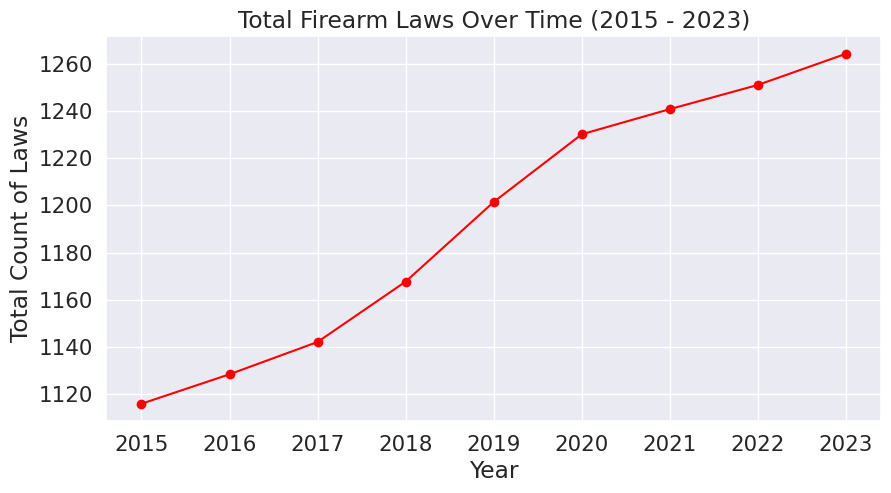

In [90]:
time_series = rand_df.groupby('year')['year_frac'].sum()
plt.figure(figsize = (10, 5))
time_series.plot(marker = 'o', color = 'red')
plt.xlabel('Year')
plt.ylabel('Total Count of Laws')
plt.title('Total Firearm Laws Over Time (2015 - 2023)')
plt.grid(True)

In [91]:
rand_by_state_year = rand_df.groupby(['state', 'year', 'law_class'])['year_frac'].sum().reset_index().rename(columns={'year_frac': 'law_count'})
rand_giffords_df = pd.merge(giffords_2015_to_2025, rand_by_state_year, left_on=['State', 'Year'], right_on=['state', 'year']).drop(columns=['state', 'year'])

# c. Visualization 2b - *RAND* Firearm Laws Over Time by *NCSL* State Party Control

**The following visualization breaks down total RAND firearm law counts by year and state party control. We produce two plots: one showing raw totals across all states per party group, and one showing the average per state to account for the unequal number of Democrat vs. Republican-controlled states in the dataset. Together they allow us to examine whether political control of state governments is associated with the volume of firearm legislation over time.**

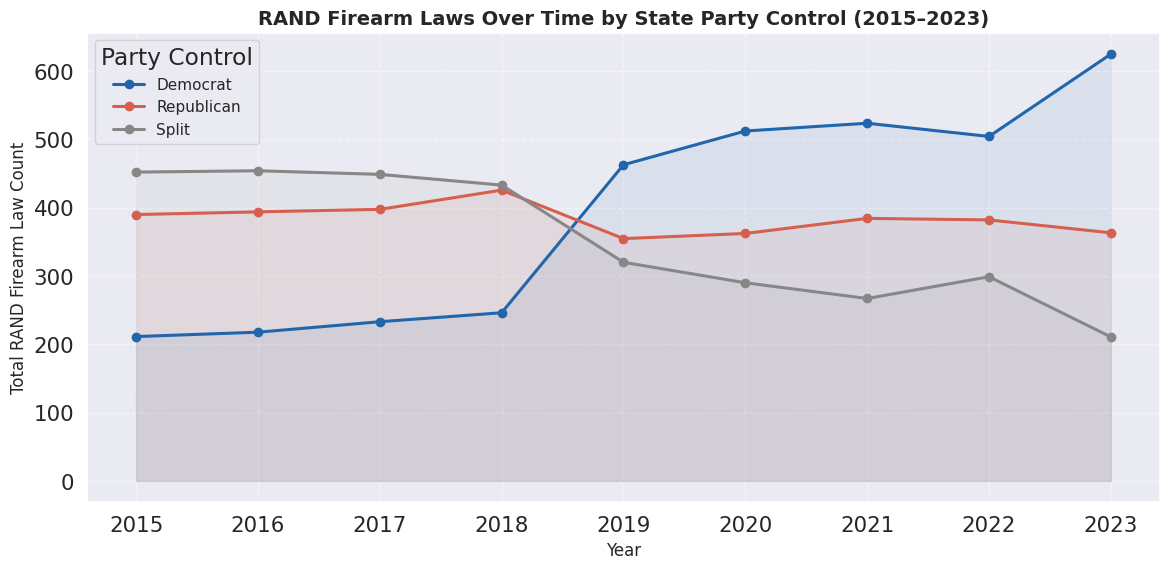

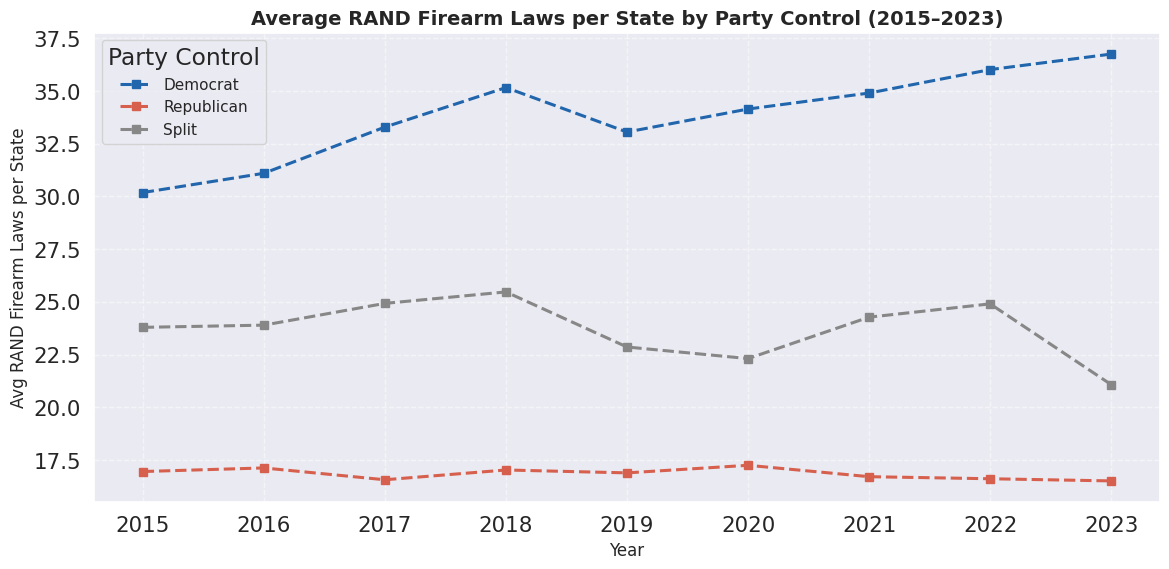

In [92]:
# Merge rand_df with statecontrol_2015_to_2025 on state/year
rand_state = rand_df.rename(columns={'state': 'State', 'year': 'Year'})

rand_control = pd.merge(rand_state, statecontrol_2015_to_2025, on=['State', 'Year'], how='inner')

# Remove Nebraska (N/A unicameral legislature)
rand_control = rand_control[rand_control['State Control'] != 'N/A']

# Map party control labels for clarity
party_labels = {'D': 'Democrat', 'R': 'Republican', 'S': 'Split'}
rand_control['Party Control'] = rand_control['State Control'].map(party_labels)

# Sum law counts by year and party control
laws_by_party_year = rand_control.groupby(['Year', 'Party Control'])['year_frac'].sum().reset_index().rename(columns={'year_frac': 'Total Laws'})

laws_pivot = laws_by_party_year.pivot(index='Year', columns='Party Control', values='Total Laws')

# Plot 1: Total law count by party
fig, ax = plt.subplots(figsize=(12, 6))

party_colors = {'Democrat': '#2166ac', 'Republican': '#d6604d', 'Split': '#878787'}

for party, color in party_colors.items():
    if party in laws_pivot.columns:
        ax.plot(laws_pivot.index, laws_pivot[party], marker='o', label=party, color=color, linewidth=2.2)
        ax.fill_between(laws_pivot.index, laws_pivot[party], alpha=0.08, color=color)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total RAND Firearm Law Count', fontsize=12)
ax.set_title('RAND Firearm Laws Over Time by State Party Control (2015–2023)', fontsize=14, fontweight='bold')
ax.legend(title='Party Control', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(sorted(laws_by_party_year['Year'].unique()))
plt.tight_layout()
plt.show()

# Plot 2: Average laws per state by party (normalizes for unequal group sizes)
laws_avg_party_year = (
    rand_control.groupby(['Year', 'Party Control', 'State'])['year_frac']
    .sum()
    .reset_index()
    .groupby(['Year', 'Party Control'])['year_frac']
    .mean()
    .reset_index()
    .rename(columns={'year_frac': 'Avg Laws per State'})
)

laws_avg_pivot = laws_avg_party_year.pivot(index='Year', columns='Party Control', values='Avg Laws per State')

fig, ax = plt.subplots(figsize=(12, 6))

for party, color in party_colors.items():
    if party in laws_avg_pivot.columns:
        ax.plot(laws_avg_pivot.index, laws_avg_pivot[party], marker='s', label=party, color=color, linewidth=2.2, linestyle='--')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg RAND Firearm Laws per State', fontsize=12)
ax.set_title('Average RAND Firearm Laws per State by Party Control (2015–2023)', fontsize=14, fontweight='bold')
ax.legend(title='Party Control', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(sorted(laws_avg_party_year['Year'].unique()))
plt.tight_layout()
plt.show()


**The two plots above break down RAND firearm law counts by state party control across total laws and average laws per state normalized for group size. Democrat-controlled states consistently held the highest law count throughout the period, with a notable acceleration beginning in 2018 that widened the gap between party groups through 2023. The per-state average plot is the more analytically meaningful of the two; it corrects for the fact that there are substantially more Republican-controlled states in the dataset, which would otherwise inflate their raw total. The per-state average plot confirms this is not a volume artifact — Democrat-controlled states averaged 30 laws per state in 2015 and grew steadily to 37 laws by 2023, while Republican-controlled states held virtually flat at around 17 laws per state per year throughout the entire period. The divergence between parties at the inflection point (same as in Visualization 2a) suggests that high-profile shooting events during this period, such as the 2017 Mandalay Bay Shooting or the 2018 Parkland High School Shooting, may have triggered differential legislative responses depending on which party held power.**

# d. Summary Table Combining *Giffords Annual Gun Law Scorecard* with *RAND* Laws

**The following table combines our datasets to better understand the summary statistics for the main variables used in our analysis, especially between the count of laws and the general rank and death rate ranking. The dataset consists of state-year observations from 2015 to 2023. The main outcome variable is the number of mass shootings per state-year (`Num Mass Shootings`), with additional measures capturing severity through the number of victims killed (`Num Killed`) and injured (`Num Injured`). The key explanatory variable is the number of firearm laws (`law_count`), which reflects the total number of active laws weighted by the fraction of the year they were in effect. The dataset also includes state rankings of gun law strength (`Rank`) and gun death rates (`Gun Death Rate Rank`).**

In [93]:
#count incidents per state-year
shootings_by_state_year = mass_shootings.groupby(['State', 'Year']).size().reset_index(name='Num Mass Shootings')

#count killings per state-year
shootings_by_state_year['Num Killed'] = mass_shootings.groupby(['State','Year'])['Victims Killed'].sum().values

#count injured per state-year
shootings_by_state_year['Num Injured'] = mass_shootings.groupby(['State','Year'])['Victims Injured'].sum().values

rand_totals = (rand_giffords_df.groupby(['State','Year','Giffords_Rank','Gun Death Rate Rank'])['law_count'].sum().reset_index())

shooting_laws_df = pd.merge(rand_totals, shootings_by_state_year, on=['State','Year'], how='left')

shooting_laws_df[['Num Mass Shootings','Num Killed','Num Injured']] = shooting_laws_df[['Num Mass Shootings','Num Killed','Num Injured']].fillna(0)

shooting_laws_df[['law_count', 'Num Mass Shootings', 'Num Killed', 'Num Injured', 'Giffords_Rank', 'Gun Death Rate Rank']].describe()

,law_count,Num Mass Shootings,Num Killed,Num Injured,Giffords_Rank,Gun Death Rate Rank
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,23.022447,9.655556,9.888889,39.973333,2.366667,25.675556
std,10.978676,12.396890,13.685982,55.224984,1.523754,14.355232
min,9.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,15.000000,1.000000,0.250000,3.000000,1.000000,13.000000
50%,19.000000,5.000000,5.000000,18.500000,2.000000,25.500000
75%,27.000000,14.000000,15.000000,55.750000,4.000000,38.000000
max,57.444000,86.000000,84.000000,441.000000,5.000000,50.000000


## e. Correlation Matrix for Mass Shootings and State-Year Laws

**The correlation matrix below examines the relationship between *RAND* law counts, *Giffords* rank, and our three shooting outcome variables. `law_count` and `Giffords_Rank` are moderately positively correlated, which makes sense—we intuitively believe states with more active firearm laws on the books tend to receive higher *Giffords* scores. More notably, `Num Mass Shootings` shows a weak positive correlation with `law_count`, which may seem counterintuitive but likely reflects population and urbanization factors: more populated states such as California or Illinois have both more laws but more incidents. `Num Killed` and `Num Injured` follow a similar pattern. This ultimately shows us that raw counts without population controls are very limited in predicting policy effectiveness.**

In [94]:
shooting_laws_df[['law_count', 'Num Mass Shootings', 'Num Killed', 'Num Injured', 'Giffords_Rank']].corr()

,law_count,Num Mass Shootings,Num Killed,Num Injured,Giffords_Rank
law_count,1.000000,0.360184,0.242821,0.336124,0.894636
Num Mass Shootings,0.360184,1.000000,0.861810,0.920039,0.233783
Num Killed,0.242821,0.861810,1.000000,0.858311,0.105766
Num Injured,0.336124,0.920039,0.858311,1.000000,0.213863
Giffords_Rank,0.894636,0.233783,0.105766,0.213863,1.000000


## f. Visualization 3 - Number of Mass Shootings By State

**Here we visualized the top 10 states in terms of numbers of mass shootings. It is important to note that we are currently using total shootings as a proxy for school shootings due to data access issues. We still find that this is valuable, showcasing that disparities and laws still results in comparable shooting numbers (see Texas and California).**

<Axes: xlabel='State'>

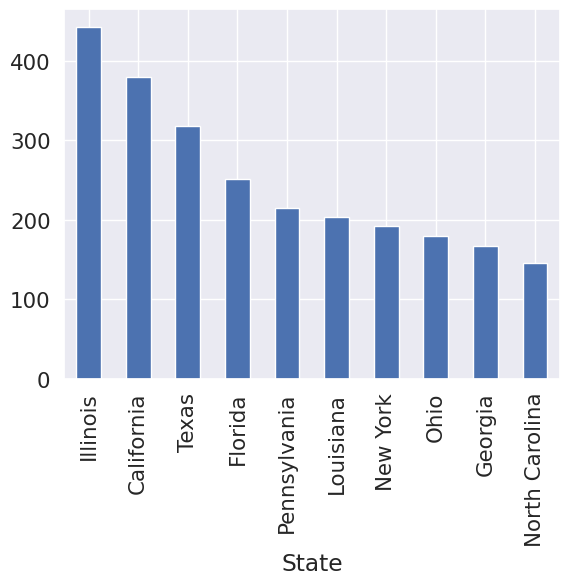

In [95]:
top_states = shooting_laws_df.groupby('State')['Num Mass Shootings'].sum().sort_values(ascending=False).head(10)
top_states.plot(kind='bar')

## g. Visualization 4 - Before & After Law Changes

**The visualization shows the average number of mass shootings before and after major firearm law changes, where year 0 is the year the law changes occurred, depicted by the vertical red line. Before the change (years -5 to -1), shootings are fairly stable, staying around 10-12 per year. At year 0, there is a noticeable increase in shootings, and levels stay higher in the years after, with some fluctuation. Overall, mass shooting seem to rise around the time of the law change and stay elevated afterward, with no clear decrease immediately following the policy change.**

Text(0, 0.5, 'Average Number of Shootings')

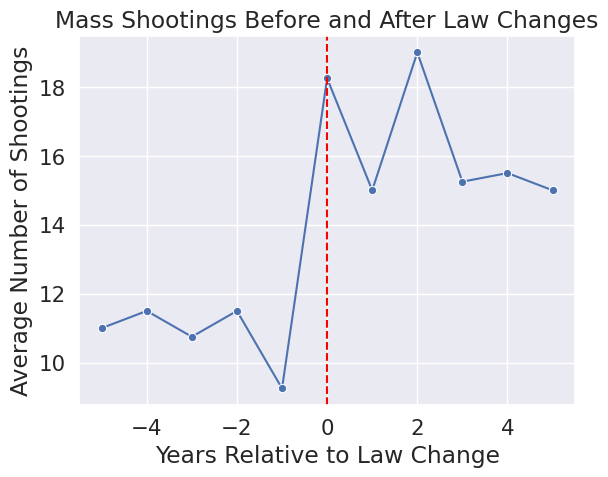

In [96]:
shooting_laws_df['law_change'] = shooting_laws_df.groupby('State')['law_count'].diff()
treated_states = shooting_laws_df[shooting_laws_df['law_change'] > 5][['State', 'Year']]
treated_states = treated_states.rename(columns={'Year': 'Treatment Year'})
diff_diff_df = pd.merge(shooting_laws_df, treated_states, on='State', how='left')
diff_diff_df['Event Time'] = diff_diff_df['Year'] - diff_diff_df['Treatment Year']

event_df = diff_diff_df[(diff_diff_df['Event Time'] >= -5) & (diff_diff_df['Event Time'] <= 5)]

avg_effect = event_df.groupby('Event Time')['Num Mass Shootings'].mean().reset_index()

sns.lineplot(data=avg_effect, x='Event Time', y='Num Mass Shootings', marker='o')
plt.axvline(0, linestyle='--', color='red')  # treatment point
plt.title('Mass Shootings Before and After Law Changes')
plt.xlabel('Years Relative to Law Change')
plt.ylabel('Average Number of Shootings')

## h. Visualization 5 - Annual Mass Shooting Fatalities by State (2015-2023)

**For this visualization, the interactive nature of this time series makes it easy to isolate and track the total number of fatalities in mass shooting incidents in all 50 states. This is helpful for our exploratory data analysis because it combines the number of fatalities in each state with the Giffords Law Rank and Gun Death Rate Rank for each year by state for a comprehensive understanding of the trajectories of each state regarding fatalities and firearm law policy changes over the nine years.**

In [97]:
pio.renderers.default = 'colab'
state_data = shooting_laws_df.groupby(['State', 'Year']).agg({'Giffords_Rank': 'first', 'Gun Death Rate Rank': 'first', 'Num Injured': 'first',
                                                                'Num Killed': 'first', 'Num Mass Shootings': 'first'}).reset_index()
nan_cols = ['Num Killed', 'Num Injured', 'Num Mass Shootings']
state_data[nan_cols] = state_data[nan_cols].fillna(0)
fig = px.line(state_data, x = 'Year', y = 'Num Killed', color = 'State', title = 'Trend of Mass Shooting Fatalities by State (2015 - 2023)', labels = {'Num Killed': 'Victims Killed', 'Year': 'Year'}, markers = True, hover_data = {'Giffords_Rank': True, 'Gun Death Rate Rank': True})
fig.update_layout(xaxis=dict(rangeslider = dict(visible = True), type = 'linear'), yaxis_title = 'Total Victims Killed', legend_title = 'State', hovermode = 'x unified')
fig.show()
fig.write_html("index.html", include_plotlyjs="cdn")

# i. Key Takeaways from Our EDA

**For this EDA, we used mass shooting data because we are having issues accessing the K-12 school shooting data, which is what we are mainly focusing on. Later on in the project, we hope to gain access to the proper databases to narrow our scope to school shootings, but this was a good starting point to understand state policy and fatalities. The Folium Map visualization serves as a great representation of the significance of geography and politics on firearm laws. The map shows a clear distinction where strict firearm laws (rank 5) are located in the Northeast and the West Coast, and states with minimal firearm laws are in the South and Midwest (rank 1). This suggests that political views are at work in determining the policies in specific regions. From visualization 2, we were able to gather that there has been an increase in legislative action after 2017-2019, which could suggest that mass shooting events during this time period triggered the number of laws passed. Visualization 3 is where we begin to see that stricter firearm policies might not automatically correlate to less firearm violence. California is among the top 10 states with the highest number of mass shootings, despite having some of the strictest firearm laws. However, it is important to note that Texas is also among the top 10 states, and they have very minimal firearm laws; it could be due to California's large population. From the 4th visualization, it is evident that between -5 and -1 years the average number of shootings remains around 10 to 12 per year, and once there was a change in policy and was enacted, there was an increase in shooting incidents, which demonstrates that policy changes do not instantly mitigate violence. This could also suggest that states that pass the most firearm laws are not effective at stopping a rise in mass shootings. Lastly, visualization 5, shows how there is no specific trend that defines the frequency of fatalities because there are several spikes in the data on various states in different years. Using the Giffords Rank data, this allows us to understand that states with high ranks are not immune to the spikes in mass shootings and affirms that more legislative action against firearms does not completely end mass shootings in those states.**

# Section IV. Modeling

## a. Predicting Gun Law Severity from Mass Shooting Statistics

**We begin by aggregating mass shooting incidents per state per year, then create a one-year lag so that shooting counts from year T can be joined to law strength data from year T+1.**

In [98]:
# Aggregating the count of mass shootings per state per year
shooting_counts = (mass_shootings.groupby(['Year', 'State']).size().reset_index(name='Shooting Count'))

# Lagging Shooting Counts Data by 1 Year
shooting_counts_lag = shooting_counts.copy()
shooting_counts_lag['Lag_1'] = shooting_counts_lag['Year'] - 1
shooting_counts_lag

,Year,State,Shooting Count,Lag_1
0,2015,Alabama,4,2014
1,2015,Arizona,6,2014
2,2015,Arkansas,2,2014
3,2015,California,27,2014
4,2015,Colorado,3,2014
...,...,...,...,...
449,2025,Virginia,10,2024
450,2025,Washington,7,2024
451,2025,West Virginia,1,2024
452,2025,Wisconsin,4,2024


**Here we merge the lagged shooting counts with Giffords rankings. The left_on='Lag_1' join matches each shooting year to the law rank from the following year, reflecting the idea that legislatures respond to prior events rather than concurrent ones.**

In [99]:
# Merge with giffords on Year and State
giffords_merge = shooting_counts_lag.merge(giffords_2015_to_2025[['Year', 'State', 'Giffords_Rank']], left_on=['Lag_1', 'State'], right_on=['Year', 'State'], how='left')

# Drop rows where we don't have a gun law rank (no giffords data for that state/year)
giffords_merge = giffords_merge.dropna(subset=['Giffords_Rank'])

## b. Trying a Multinomial Logistic Regression Model

**Our first attempt uses multinomial logistic regression with shooting count as the sole predictor of Giffords rank across all five levels. The feature predictor (X) is shooting count per year, and the target variable (y) is the Giffords rank on a 1-5 scale. We split the data twice — first into train/test, then train/validate so we can evaluate both fit and generalizability.**

In [118]:
#multinomial regression

X = giffords_merge[['Shooting Count']]
y = giffords_merge['Giffords_Rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, train_size=0.75, test_size=0.25, random_state=42)

logit_model = LogisticRegression(penalty=None, class_weight='balanced')
logit_model.fit(X_train, y_train)

# check the accuracy on the training and validation sets
print("Accuracy on training set: ", logit_model.score(X_train, y_train))
print("Accuracy on validation set: ", logit_model.score(X_validate, y_validate))

Accuracy on training set:  0.3458333333333333
Accuracy on validation set:  0.3950617283950617


**Training accuracy came in at ~34.58% and validation at ~39.5%, both well below what we'd need for a reliable classifier. This is most likely due to granularity, because we are trying to classify 5 ranks using a single predictor, which does not allow for a great representation of our data.**

In [122]:
predictions = logit_model.predict(X_validate)
probabilities = logit_model.predict_proba(X_validate)

compare = X_validate.copy()
compare['prediction'] = list(predictions) # need to cast as a list because the array above has wrong shape
compare['probability'] = probabilities[:, 1] # the element of the array for probability of true
logit_matrix = metrics.confusion_matrix(y_validate, compare['prediction'])

print("Coefficient:", logit_model.coef_[0][0])
print("Intercept:", logit_model.intercept_[0])
print("\nConfusion Matrix:\n", logit_matrix)
logit_cf_recall = metrics.recall_score(y_validate, compare['prediction'], average='weighted')
logit_cf_precision = metrics.precision_score(y_validate, compare['prediction'], average='weighted')
print("logistic regression classifer recall: ",logit_cf_recall)
print("logistic regression classifer precision: ", logit_cf_precision)

Coefficient: -0.015023030690758412
Intercept: 0.20100773363676894

Confusion Matrix:
 [[27  2  0  0 14]
 [ 2  1  0  0  1]
 [ 9  0  0  0  1]
 [ 3  1  0  0  2]
 [12  2  0  0  4]]
logistic regression classifer recall:  0.3950617283950617
logistic regression classifer precision:  0.31907474465126456


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



**Interpreting Coefficient & Intercept**



*   Coefficient (-0.0150): for every additional mass shooting in a state-year, the predicted *Giffords* rank goes down by 0.015. The model thinks states with more shootings are slightly more likely to have weaker gun laws, which intuitively makes sense, but the effect is so small it's practically meaningless as a predictor.
*   Intercept (0.201): Baseline log-odds when shooting count is zero. Carries basically no interpretive weight here on its own.


**Takeaway:** A coefficient this close to zero means the model learned almost nothing useful from shooting count. The near-zero coefficient is why our following confusion matrix shows the model almost entirely collapsing predictions into ranks 1 and 5 and ignoring the middle. It's not finding enough signal to differentiate between levels, so it's just defaulting to the extremes.

Text(86.25, 0.5, 'True Label')

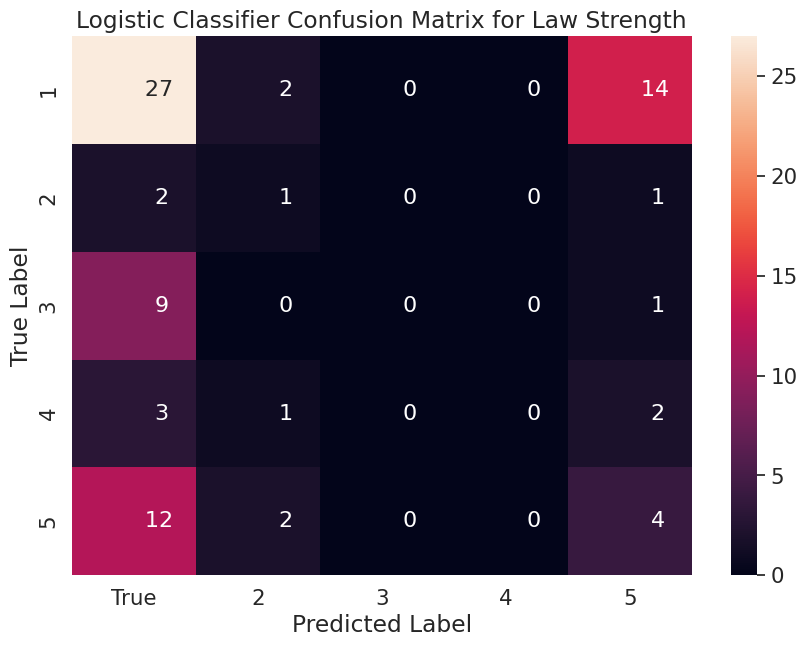

In [123]:
# Display confusion matrix as heatmap
logit_cm = pd.DataFrame(logit_matrix, range(1, 6), range(1, 6))
logit_cm = logit_cm.rename(index=str, columns={0:'False', 1:'True'})
#logit_cm.index = ['False', 'True']
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(logit_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})

plt.title("Logistic Classifier Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

**From our previous accuracy levels, we could infer that the multinomial regression is basically guessing across all five ranks. This is evidently supported by the confusion matrix, which visually demonstrates that the classifier has a very hard time distinguishing between the ranks solely based off shooting count as a predictor. Collapsing complex state policy into five ranks and trying to predict it from shooting count alone doesn't give the model enough to work with. This leads us to simplify our target variable and revisit our approach with the following Binomial Regression Model.**

## c. Trying a Binomial Logistic Regression Model



**The multinomial model revealed that the real distinction in our data is between the extremes—ranks 1 and 5—with ranks 2-4 adding little predictive signal. binarize the Giffords rank into a single `Strong_Laws variable`, collapsing the 1-5 scale into 0 (weak, ranks 1-3) and 1 (strong, ranks 4-5). This is a significant reduction in granularity, going from letter grades to a 5-point scale to now a single bit, but the multinomial results suggest the middle ground simply isn't meaningful here.**

In [100]:
giffords_merge['Strong_Laws'] = (giffords_merge['Giffords_Rank'] >= 4).astype(int)
giffords_merge ## USE YEAR_Y

,Year_x,State,Shooting Count,Lag_1,Year_y,Giffords_Rank,Strong_Laws
42,2016,Alabama,15,2015,2015.0,1.0,0
43,2016,Arizona,4,2015,2015.0,1.0,0
44,2016,Arkansas,3,2015,2015.0,1.0,0
45,2016,California,45,2015,2015.0,5.0,1
46,2016,Colorado,4,2015,2015.0,3.0,0
...,...,...,...,...,...,...,...
449,2025,Virginia,10,2024,2024.0,4.0,1
450,2025,Washington,7,2024,2024.0,5.0,1
451,2025,West Virginia,1,2024,2024.0,1.0,0
452,2025,Wisconsin,4,2024,2024.0,3.0,0


**Switching to a binomial setup using our new `Strong_Laws` variable reduces the problem to a simpler strong vs. weak classification, but we're still relying solely on shooting count as the predictor. From taking the letter grades of Giffords and turning them from an A-D scale including +- values, to a 1-5 scale, and now down to 0-1. But what we have learned from this is that the middle levels of law severity aren't significant predictors of mass shootings, but rather relative strength.**

In [124]:
# the data we're working with (binomial logistic regression)

X = giffords_merge[['Shooting Count']]
y = giffords_merge['Strong_Laws']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, train_size=0.75, test_size=0.25, random_state=42)

In [126]:
logit_model = LogisticRegression(penalty=None, class_weight='balanced')
logit_model.fit(X_train, y_train)

# check the accuracy on the training and validation sets
print("Accuracy on training set: ", logit_model.score(X_train, y_train))
print("Accuracy on validation set: ", logit_model.score(X_validate, y_validate))

Accuracy on training set:  0.5916666666666667
Accuracy on validation set:  0.5802469135802469


In [130]:
predictions = logit_model.predict(X_validate)
probabilities = logit_model.predict_proba(X_validate)

compare = X_validate.copy()
compare['prediction'] = list(predictions) # need to cast as a list because the array above has wrong shape
compare['probability'] = probabilities[:, 1] # the element of the array for probability of true
logit_matrix = metrics.confusion_matrix(y_validate, compare['prediction'])

print("Coefficient:", logit_model.coef_[0][0])
print("Intercept:", logit_model.intercept_[0])
print("\nConfusion Matrix:\n", logit_matrix)
logit_cf_recall = metrics.recall_score(y_validate, compare['prediction'])
logit_cf_precision = metrics.precision_score(y_validate, compare['prediction'])
logit_cf_auc_roc_score = metrics.roc_auc_score(y_validate, compare['prediction'])
tn, fp, fn, tp = logit_matrix.ravel()
logit_cf_fpr = fp / (fp + tn)
print("logistic regression classifer recall: ",logit_cf_recall)
print("logistic regression classifer precision: ", logit_cf_precision)
print("logistic regression classifer false positive rate: ",logit_cf_fpr)
print("logistic regression classifer AUC-ROC score: ", logit_cf_auc_roc_score)

Coefficient: 0.03414201985003312
Intercept: -0.4470444805284293

Confusion Matrix:
 [[40 17]
 [17  7]]
logistic regression classifer recall:  0.2916666666666667
logistic regression classifer precision:  0.2916666666666667
logistic regression classifer false positive rate:  0.2982456140350877
logistic regression classifer AUC-ROC score:  0.4967105263157895


**Binomial model performance improves slightly over the multinomial model, but the classifier still produces a high rate of false positives (~29.8%). Combined with an AUC-ROC of 0.497—which is essentially a coin flip—this confirms the model is performing at near-random levels. This tells us shooting count alone is not a sufficient predictor of law strength, which motivates the upcoming addition of state party control data.**

Text(86.25, 0.5, 'True Label')

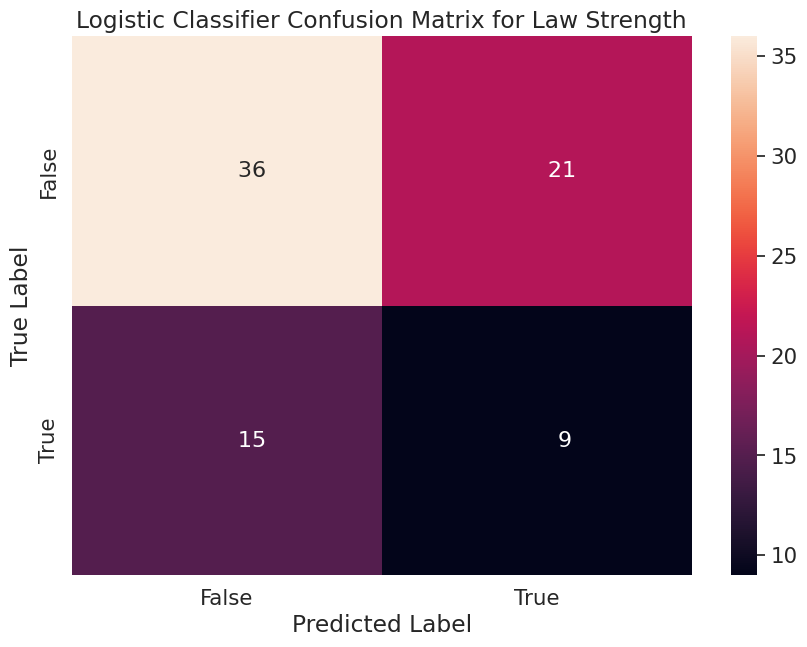

In [36]:
# Display confusion matrix as heatmap
logit_cm = pd.DataFrame(logit_matrix, range(2), range(2))
logit_cm = logit_cm.rename(index=str, columns={0:'False', 1:'True'})
logit_cm.index = ['False', 'True']
plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(logit_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})

plt.title("Logistic Classifier Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

**To investigate `Strong_Laws` as a valid variable within modeling, we now plan to see if state control (congressional control and governor party) per year can help predict both state strength in gun laws, and amounts of mass shootings. We recognize that this might be telling us something a little more black and white: if a state's congressional party control and governance control has more of an effect on gun law strength, and if that in turn defines how many mass shootings occur in a given year. This could lead us to the result of state control being a primary indicator of a lot of the factors that go into mass shootings, as we have discussed guns as only being a part. In our final presentation we may even want to look into mental health resources as associated with state party control as another factor in mass shootings occurring.**

## d. Predicting Law Strength With State-Control Data

**Because our data was incompatible with both the multinomial and binomial logistic regression models (most likely due to the small number of observations and the granularity of the data), we wanted to see if we could get stronger predictions for gun law strength by including data on state-government control.**

**Since shooting count alone couldn't predict law strength, we bring in state government control data and restructure our merge to use the lag: shooting counts from year T join to law and control data from year T+1. Nebraska is excluded throughout because its unicameral nonpartisan legislature doesn't map to the D/R/S categories used elsewhere.**

In [108]:
#merge all the dfs

lag_merge = pd.merge(giffords_control_df, shooting_counts_lag, left_on=['State', 'Year'], right_on=['State', 'Lag_1'], how='inner', suffixes=('', '_shooting'))

lag_merge = lag_merge[lag_merge['State Control'] != 'N/A']

model_df = pd.get_dummies(lag_merge, columns=['State Control'], drop_first=True)

model_df['Strong_Laws'] = (model_df['Giffords_Rank'] >= 4).astype(int)

model_df

,Year,State,Giffords_Rank,Gun Death Rate Rank,Year_shooting,Shooting Count,Lag_1,State Control_R,State Control_S,Strong_Laws
0,2015,California,5,42,2016,45,2015,False,False,1
1,2015,Connecticut,5,47,2016,6,2015,False,False,1
2,2015,New Jersey,5,45,2016,9,2015,False,True,1
3,2015,Maryland,5,36,2016,11,2015,False,True,1
4,2015,Massachusetts,5,49,2016,3,2015,False,True,1
...,...,...,...,...,...,...,...,...,...,...
397,2024,Tennessee,1,6,2025,16,2024,True,False,0
398,2024,Texas,1,24,2025,37,2024,True,False,0
399,2024,Utah,1,25,2025,1,2024,True,False,0
400,2024,West Virginia,1,19,2025,1,2024,True,False,0


**We pull in`Num Mass Shootings`, `Num Killed`, and `Num Injured` aligned to the shooting year so they're available as features or outcomes in downstream models.**

In [109]:
response_vars = shooting_laws_df[['State', 'Year', 'Num Mass Shootings', 'Num Killed', 'Num Injured']]

model_df = pd.merge(model_df, response_vars, left_on=['State', 'Year_shooting'], right_on=['State', 'Year'], how='left', suffixes=('', '_resp'))

# Fill NaN response values with 0 (states/years with no recorded shootings)
model_df[['Num Mass Shootings', 'Num Killed', 'Num Injured']] = model_df[['Num Mass Shootings', 'Num Killed', 'Num Injured']].fillna(0)
model_df

,Year,State,Giffords_Rank,Gun Death Rate Rank,Year_shooting,Shooting Count,Lag_1,State Control_R,State Control_S,Strong_Laws,Year_resp,Num Mass Shootings,Num Killed,Num Injured
0,2015,California,5,42,2016,45,2015,False,False,1,2016.0,45.0,31.0,190.0
1,2015,Connecticut,5,47,2016,6,2015,False,False,1,2016.0,6.0,2.0,34.0
2,2015,New Jersey,5,45,2016,9,2015,False,True,1,2016.0,9.0,3.0,40.0
3,2015,Maryland,5,36,2016,11,2015,False,True,1,2016.0,11.0,12.0,47.0
4,2015,Massachusetts,5,49,2016,3,2015,False,True,1,2016.0,3.0,2.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,2024,Tennessee,1,6,2025,16,2024,True,False,0,NaN,0.0,0.0,0.0
390,2024,Texas,1,24,2025,37,2024,True,False,0,NaN,0.0,0.0,0.0
391,2024,Utah,1,25,2025,1,2024,True,False,0,NaN,0.0,0.0,0.0
392,2024,West Virginia,1,19,2025,1,2024,True,False,0,NaN,0.0,0.0,0.0


**We run the same binomial logistic regression with state control dummies added alongside shooting count as predictors.**

In [132]:
X = model_df[['Shooting Count', 'State Control_R', 'State Control_S']]
y = model_df['Strong_Laws']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_validate, y_train, y_validate = train_test_split(X_train, y_train, train_size=0.75, test_size=0.25, random_state=42)

logit_multi_model = LogisticRegression(penalty=None, class_weight='balanced')
logit_multi_model.fit(X_train, y_train)
print("Accuracy on training set: ", logit_multi_model.score(X_train, y_train))
print("Accuracy on validation set: ", logit_multi_model.score(X_validate, y_validate))

Accuracy on training set:  0.826271186440678
Accuracy on validation set:  0.7974683544303798


**The addition of state control dummies produces a meaningful jump in both training and validation accuracy over the shooting-count-only binomial model. The improvement is driven by `State Control_R` in particular, which carries strong signal about whether a state has weak gun laws. Republican-controlled states are far more likely to score in the lower *Giffords* ranks. Validation accuracy being below training accuracy is expected given our relatively small sample, and the gap is not large enough to indicate serious overfitting.**

Text(86.25, 0.5, 'True Label')

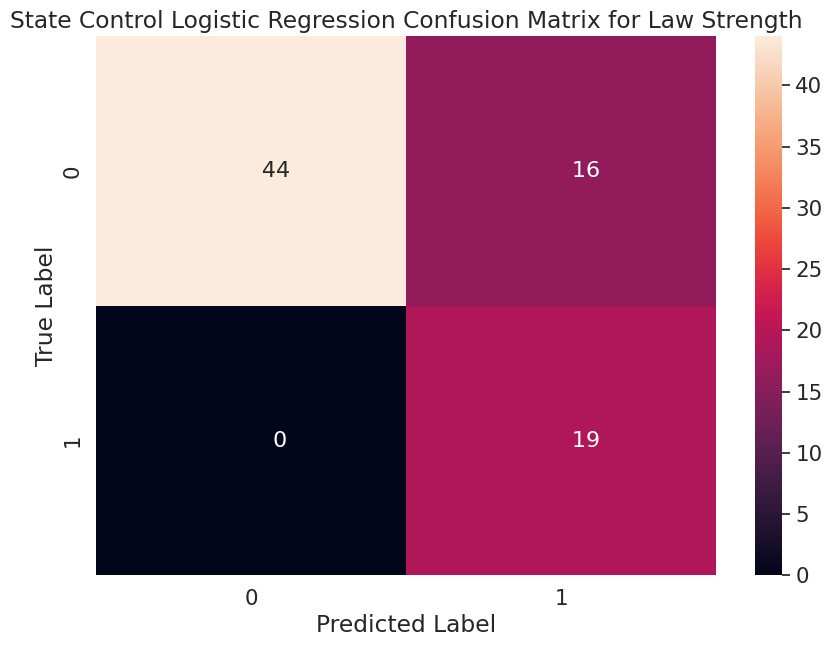

In [133]:
predictions = logit_multi_model.predict(X_validate)
logit_matrix = metrics.confusion_matrix(y_validate, predictions)

logit_cm = pd.DataFrame(logit_matrix, range(2), range(2))

plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(logit_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})
plt.title("State Control Logistic Regression Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

**Including state control meaningfully reduces false positives compared to the shooting-count-only model—the classifier is now much less likely to predict strong laws where none exist. This suggests party control carries real structural signal about a state's legislative behavior on firearms.**

## e. Building a Random Forest Classifier

**We follow up with a Random Forest to capture any non-linear relationships between our predictors without distributional assumptions.**

In [136]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

print("Accuracy on training set: ", rf_model.score(X_train, y_train))
print("Accuracy on validation set: ", rf_model.score(X_validate, y_validate))

Accuracy on training set:  0.885593220338983
Accuracy on validation set:  0.810126582278481


**The Random Forest trains to 88.6% accuracy on the training set and holds up well at 81.0% on the validation set—a much stronger result than either logistic regression model. The relatively small gap between training and validation accuracy suggests the model is generalizing reasonably rather than just memorizing the training data, which is a good sign given our sample size. This jump in performance over the binomial logistic regression (~50% validation) indicates the Random Forest is capturing non-linear interactions between party control and shooting counts that a linear model can't express. The feature importances in the next cell will tell us which of our three predictors is actually driving this improvement.**

Text(86.25, 0.5, 'True Label')

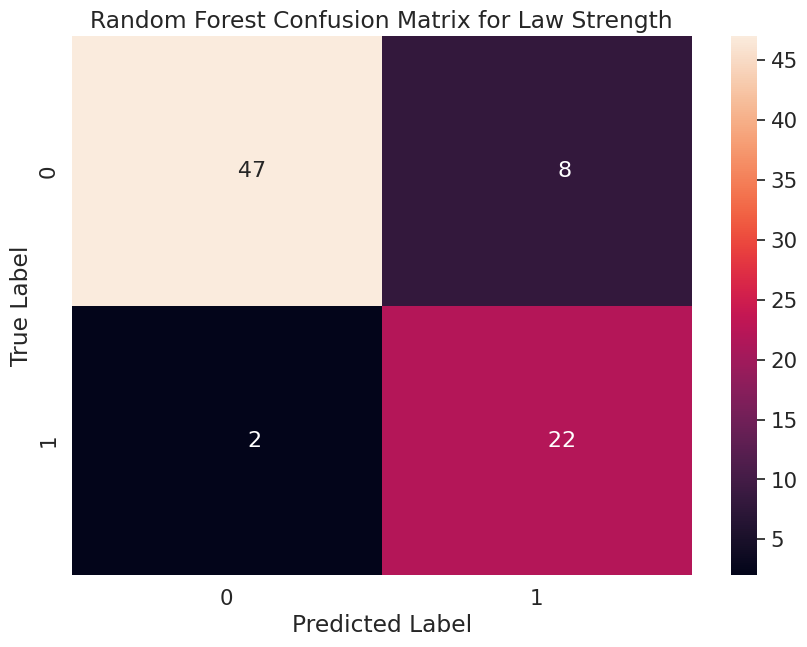

In [113]:
predictions_rf = rf_model.predict(X_validate)
rf_matrix = metrics.confusion_matrix(y_validate, predictions_rf)

rf_cm = pd.DataFrame(rf_matrix, range(2), range(2))

plt.figure(figsize = (10,7))
sns.set(font_scale=1.4)#for label size
sns.heatmap(rf_cm,
           annot=True,
           fmt = '9.0f',
           annot_kws={"size": 16})
plt.title("Random Forest Confusion Matrix for Law Strength")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

In [114]:
#Feature Importances

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)


Feature Importances:
 State Control_R    0.592357
Shooting Count     0.356954
State Control_S    0.050689
dtype: float64


**`State Control_R` comes in at ~0.623 importance versus ~0.309 for `Shooting Count`, confirming that Republican party control is a stronger predictor of gun law weakness than prior-year shooting frequency. Note that no random seed was set for the Random Forest so exact importance values may shift slightly between runs. Going forward, we plan to incorporate *RAND* law counts alongside *Giffords* and state control data to further strengthen the model.**

In [115]:
corr_cols = ['State Control_R', 'State Control_S', 'Shooting Count', 'Giffords_Rank', 'Strong_Laws']
corr_matrix = model_df[corr_cols].corr()
corr_matrix

,State Control_R,State Control_S,Shooting Count,Giffords_Rank,Strong_Laws
State Control_R,1.000000,-0.599675,-0.026862,-0.692733,-0.610577
State Control_S,-0.599675,1.000000,-0.021456,0.155166,0.081220
Shooting Count,-0.026862,-0.021456,1.000000,0.154440,0.165375
Giffords_Rank,-0.692733,0.155166,0.154440,1.000000,0.885852
Strong_Laws,-0.610577,0.081220,0.165375,0.885852,1.000000


**The correlation matrix confirms the directional relationships our models have been picking up on. `State Control_R` is negatively correlated with both `Giffords_Rank` and `Strong_Laws`, meaning Republican-controlled states consistently score lower on gun law strength—the strongest structural signal in our dataset. `Shooting Count` shows near-zero correlation with `Strong_Laws`, which is consistent with our logistic regression results and explains why shooting count alone was a poor predictor. `Giffords_Rank` and `Strong_Laws` are highly correlated as expected since `Strong_Laws` is derived directly from the rank.**